In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
print("Libraries imported Successfully.")

Libraries imported Successfully.


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1500

track_names = [f"Track_{i}" for i in range(1, n + 1)]
artists = ['Arijit Singh', 'Shreya Ghoshal', 'Neha Kakkar', 'Atif Aslam', 'Taylor Swift',
           'Ed Sheeran', 'Justin Bieber', 'Adele', 'The Weeknd', 'Imagine Dragons']

genres = ['Pop', 'Rock', 'Hip-Hop', 'Classical', 'Jazz', 'Electronic', 'Bollywood']

df = pd.DataFrame({
    'Track_Name': track_names,
    'Artist_Name': np.random.choice(artists, n),
    'Genre': np.random.choice(genres, n),
    'Danceability': np.round(np.random.uniform(0.2, 1.0, n), 2),
    'Energy': np.round(np.random.uniform(0.2, 1.0, n), 2),
    'Loudness': np.round(np.random.uniform(-60, 0, n), 2),
    'Speechiness': np.round(np.random.uniform(0, 1, n), 2),
    'Acousticness': np.round(np.random.uniform(0, 1, n), 2),
    'Instrumentalness': np.round(np.random.uniform(0, 1, n), 2),
    'Liveness': np.round(np.random.uniform(0, 1, n), 2),
    'Valence': np.round(np.random.uniform(0, 1, n), 2),
    'Tempo': np.random.randint(60, 201, n)
})

df.to_csv("Spotify_Song_Clustering_1500.csv", index=False)

print("Spotify_Song_Clustering_1500.csv created successfully!")
print(df.head())

Spotify_Song_Clustering_1500.csv created successfully!
  Track_Name    Artist_Name       Genre  Danceability  Energy  Loudness  \
0    Track_1  Justin Bieber        Jazz          0.35    0.86    -17.29   
1    Track_2     Atif Aslam  Electronic          0.22    0.49     -6.10   
2    Track_3          Adele   Classical          0.78    0.48    -25.04   
3    Track_4   Taylor Swift   Classical          0.53    0.44    -52.55   
4    Track_5  Justin Bieber   Classical          0.27    0.98    -52.72   

   Speechiness  Acousticness  Instrumentalness  Liveness  Valence  Tempo  
0         0.87          0.78              0.60      0.27     0.19    128  
1         0.50          0.27              0.67      0.63     0.54    118  
2         0.06          0.81              0.60      0.53     0.85    105  
3         0.71          0.53              0.07      0.07     0.05    165  
4         0.62          0.05              0.07      0.97     0.89     93  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track_Name        1500 non-null   object 
 1   Artist_Name       1500 non-null   object 
 2   Genre             1500 non-null   object 
 3   Danceability      1500 non-null   float64
 4   Energy            1500 non-null   float64
 5   Loudness          1500 non-null   float64
 6   Speechiness       1500 non-null   float64
 7   Acousticness      1500 non-null   float64
 8   Instrumentalness  1500 non-null   float64
 9   Liveness          1500 non-null   float64
 10  Valence           1500 non-null   float64
 11  Tempo             1500 non-null   int32  
dtypes: float64(8), int32(1), object(3)
memory usage: 134.9+ KB


In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Danceability,1500.0,0.607953,0.230055,0.20,0.4100,0.620,0.810,1.00
Energy,1500.0,0.593940,0.230259,0.20,0.3975,0.590,0.800,1.00
Loudness,1500.0,-30.507173,17.519717,-59.96,-45.7600,-30.595,-15.895,-0.01
Speechiness,1500.0,0.508447,0.286219,0.00,0.2700,0.510,0.760,1.00
Acousticness,1500.0,0.496693,0.289880,0.00,0.2500,0.500,0.750,1.00
Instrumentalness,1500.0,0.500713,0.287149,0.00,0.2600,0.500,0.740,1.00
Liveness,1500.0,0.502827,0.289059,0.00,0.2600,0.500,0.760,1.00
Valence,1500.0,0.499627,0.286143,0.00,0.2500,0.510,0.740,1.00
Tempo,1500.0,131.178667,40.669875,60.00,96.0000,132.000,166.000,200.00


In [6]:
df.tail()

,Track_Name,Artist_Name,Genre,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
1495,Track_1496,Justin Bieber,Hip-Hop,0.32,0.85,-46.04,0.61,0.96,0.19,0.95,0.49,171
1496,Track_1497,Imagine Dragons,Pop,0.37,0.59,-53.07,0.38,0.16,0.02,0.33,0.08,109
1497,Track_1498,The Weeknd,Jazz,0.70,0.25,-40.43,0.79,0.23,0.42,0.57,0.19,89
1498,Track_1499,Shreya Ghoshal,Classical,0.38,0.34,-46.77,0.87,0.23,0.09,0.40,0.32,98
1499,Track_1500,Taylor Swift,Pop,0.22,0.77,-4.48,0.85,0.02,0.09,0.40,0.42,175


In [7]:
df.isnull().sum()

Track_Name          0
Artist_Name         0
Genre               0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
dtype: int64

In [8]:
print(df.columns)

Index(['Track_Name', 'Artist_Name', 'Genre', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo'],
      dtype='object')


C:\Users\inter\AppData\Local\Temp\ipykernel_4388\2916003500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Genre', data=df, palette='Set2')


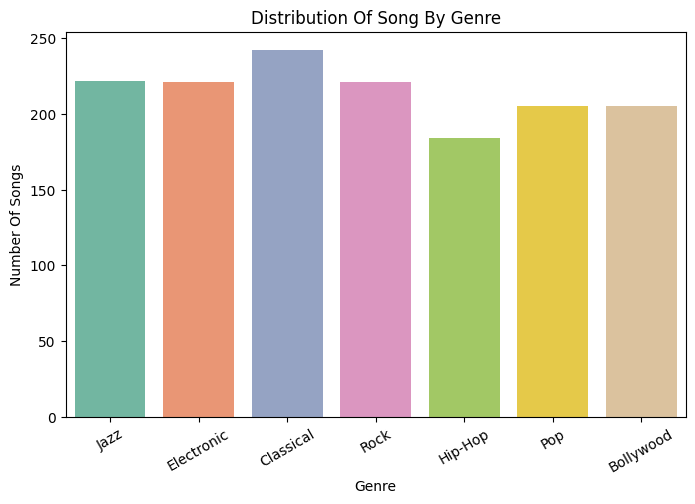

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Genre', data=df, palette='Set2')
plt.title("Distribution Of Song By Genre")
plt.xlabel("Genre")
plt.ylabel("Number Of Songs")
plt.xticks(rotation=30)
plt.show()

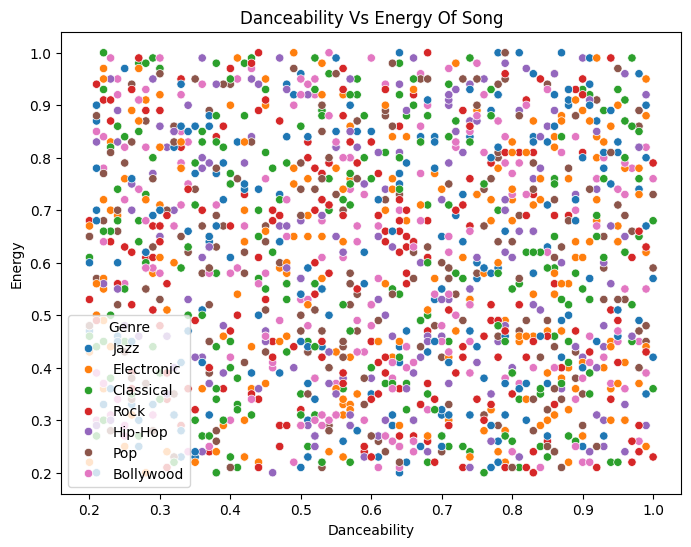

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x= 'Danceability',
    y='Energy',
    hue='Genre',
    data=df
)
plt.title("Danceability Vs Energy Of Song")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()

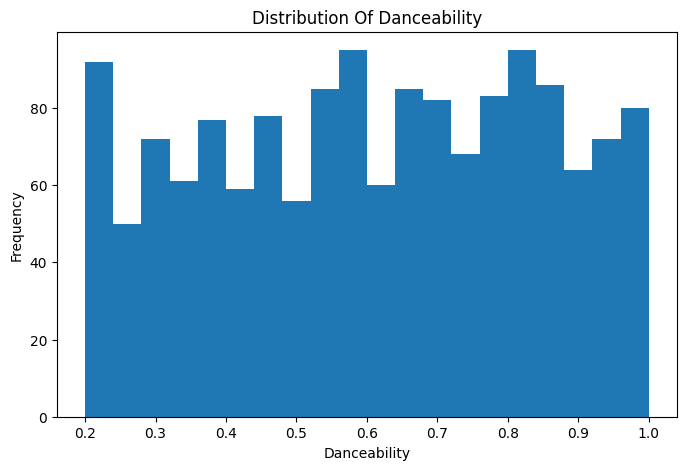

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['Danceability'], bins=20)
plt.title("Distribution Of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.show()

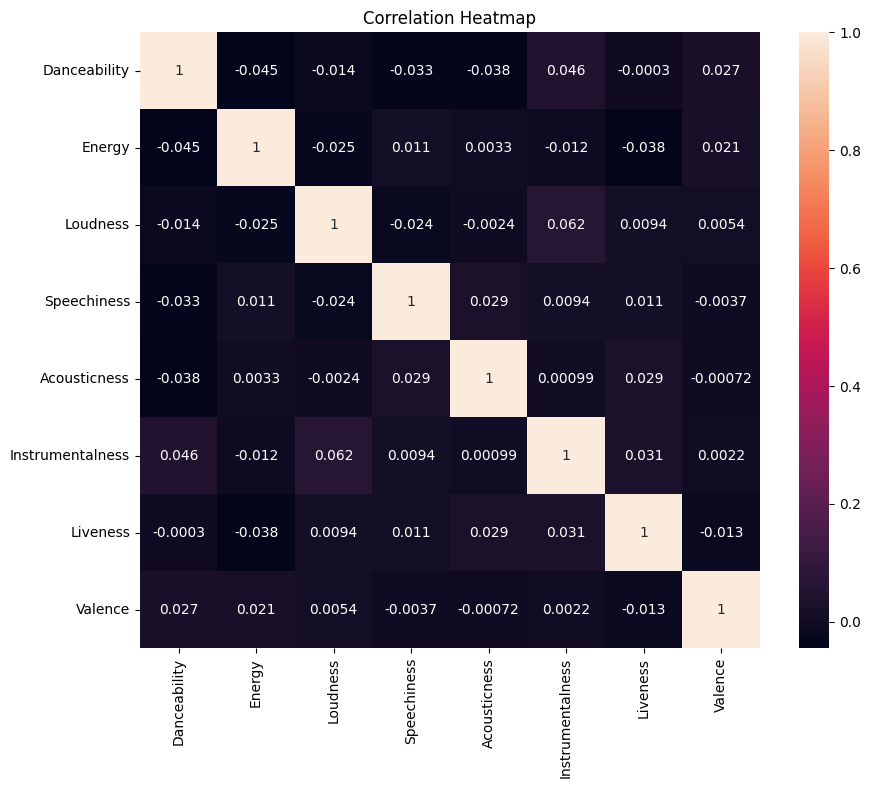

In [12]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['float64','int64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

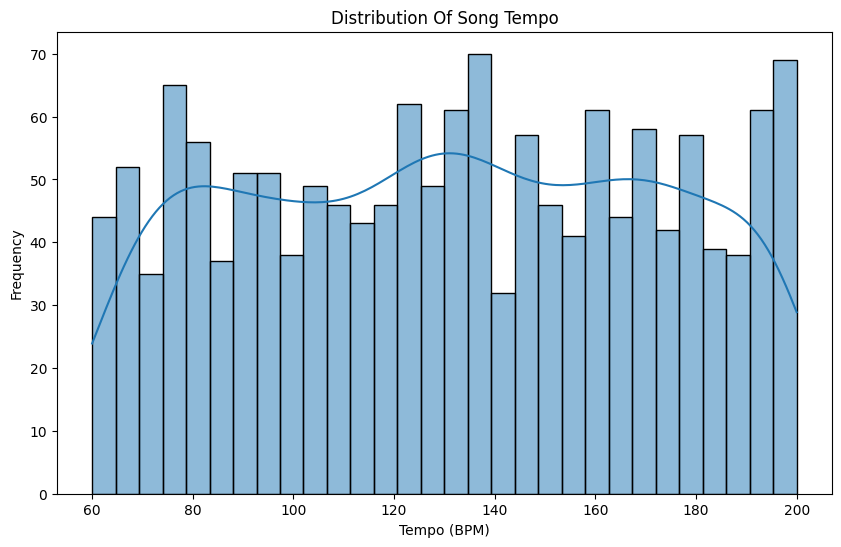

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,x='Tempo',
    bins=30,
    kde=True
)
plt.title("Distribution Of Song Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Frequency")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
features = df[['Danceability','Energy','Loudness','Speechiness','Acousticness','Instrumentalness','Liveness','Valence','Tempo']]
scaler = StandardScaler()
scaled_features =scaler.fit_transform(features)
print("Features Selected and Scaled Successfully")
print(scaled_features[:5])

Features Selected and Scaled Successfully
[[-1.12164072  1.15586808  0.75466867  1.26362532  0.97764908  0.34588186
  -0.80573243 -1.08242992 -0.07818383]
 [-1.68691077 -0.45155577  1.39359064 -0.02952102 -0.78228491  0.58973868
   0.44010285  0.14114193 -0.32414807]
 [ 0.74809868 -0.49499966  0.31216239 -1.56731666  1.08117461  0.34588186
   0.09403749  1.22487699 -0.64390158]
 [-0.33895911 -0.66877521 -1.25859215  0.7044269   0.11493634 -1.50046259
  -1.49786314 -1.57185866  0.83188385]
 [-1.46949921  1.67719473 -1.26829874  0.3898778  -1.54147212 -1.50046259
   1.61672505  1.36471377 -0.93905867]]


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Danceability"]=le.fit_transform(df["Danceability"])
df["Energy"]=le.fit_transform(df["Energy"])
df["Speechiness"]=le.fit_transform(df["Speechiness"])
df["Valences"] = le.fit_transform(df["Valence"])
df["Tempo"]=le.fit_transform(df["Tempo"])
print(df.head())

  Track_Name    Artist_Name       Genre  Danceability  Energy  Loudness  \
0    Track_1  Justin Bieber        Jazz            15      66    -17.29   
1    Track_2     Atif Aslam  Electronic             2      29     -6.10   
2    Track_3          Adele   Classical            58      28    -25.04   
3    Track_4   Taylor Swift   Classical            33      24    -52.55   
4    Track_5  Justin Bieber   Classical             7      78    -52.72   

   Speechiness  Acousticness  Instrumentalness  Liveness  Valence  Tempo  \
0           87          0.78              0.60      0.27     0.19     68   
1           50          0.27              0.67      0.63     0.54     58   
2            6          0.81              0.60      0.53     0.85     45   
3           71          0.53              0.07      0.07     0.05    105   
4           62          0.05              0.07      0.97     0.89     33   

   Valences  
0        19  
1        54  
2        85  
3         5  
4        89  


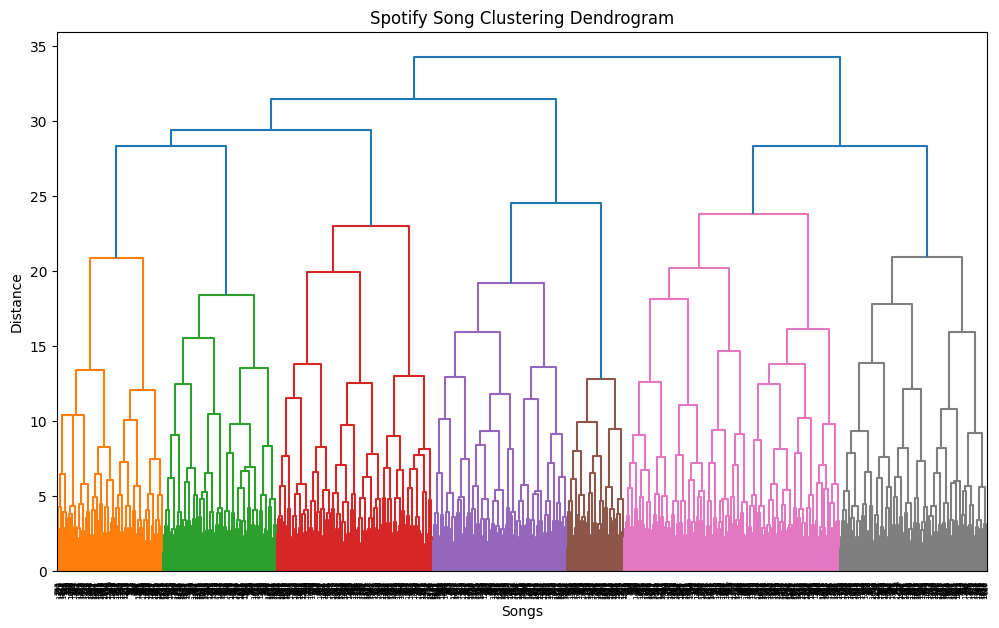

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
linked = linkage(scaled_features,method='ward')
plt.figure(figsize=(12,7))
dendrogram(
    linked, orientation='top',
    distance_sort='descending',show_leaf_counts=True
)
plt.title("Spotify Song Clustering Dendrogram")
plt.xlabel("Songs")
plt.ylabel("Distance")
plt.show()

In [21]:
cluster_model= AgglomerativeClustering(
    n_clusters=4
)
cluster = cluster_model.fit_predict(scaled_features)
df['Cluster']= cluster
df.head()

,Track_Name,Artist_Name,Genre,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Valences,Cluster
0,Track_1,Justin Bieber,Jazz,15,66,-17.29,87,0.78,0.60,0.27,0.19,68,19,0
1,Track_2,Atif Aslam,Electronic,2,29,-6.10,50,0.27,0.67,0.63,0.54,58,54,2
2,Track_3,Adele,Classical,58,28,-25.04,6,0.81,0.60,0.53,0.85,45,85,0
3,Track_4,Taylor Swift,Classical,33,24,-52.55,71,0.53,0.07,0.07,0.05,105,5,0
4,Track_5,Justin Bieber,Classical,7,78,-52.72,62,0.05,0.07,0.97,0.89,33,89,0


In [22]:
from sklearn.model_selection import train_test_split
X= df[['Danceability','Energy','Loudness','Speechiness','Acousticness','Instrumentalness','Liveness','Valence','Tempo']]
y= df['Cluster']
X_train,X_test,y_train,y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
) 

In [23]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
model = RandomForestClassifier(
    n_estimators=100, random_state=42
)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy= accuracy_score(
    y_test, prediction
)
print("Accuracy :",accuracy)
print(confusion_matrix(
    y_test, prediction
))
print(classification_report(
    y_test, prediction
))

Accuracy : 0.8066666666666666
[[90  3  4  6]
 [11 69  3  6]
 [ 5  4 43  0]
 [11  2  3 40]]
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       103
           1       0.88      0.78      0.83        89
           2       0.81      0.83      0.82        52
           3       0.77      0.71      0.74        56

    accuracy                           0.81       300
   macro avg       0.81      0.80      0.80       300
weighted avg       0.81      0.81      0.81       300



In [30]:
import pickle

with open(
"Spotify_Cluster_model.pkl",
"wb"
) as file:
    pickle.dump(model,file)


with open(
"Spotify_scaler.pkl",
"wb"
) as file:
    pickle.dump(scaler,file)

print("Saved")

Saved


In [29]:
def predict_song_cluster(input_data):

    model = pickle.load(
        open("Spotify_Cluster_model.pkl","rb")
    )

    scaler = pickle.load(
        open("Spotify_scaler.pkl","rb")
    )

    data = np.array(input_data).reshape(1,-1)

    scaled = scaler.transform(data)

    result = model.predict(scaled)

    return "Predicted Cluster : " + str(result[0])